# 02 Backpropagation Detailed | الانتشار العكسي بالتفصيل

## 📚 Learning Objectives | أهداف التعلم

By completing this notebook (~20 min), you will:
- See how gradients flow backward through the network (backpropagation)
- Use TensorFlow's GradientTape to compute gradients for a small model
- Understand why we use backprop instead of guessing weights

---

## 🌍 Real life | في الواقع

**Where is this used?** Every time you train a neural network (digit recognition, image classification, NLP), the **optimizer** uses **gradients** from backpropagation to update the weights.

**In this notebook we use** **backpropagation** (via GradientTape) to **compute gradients of the loss with respect to the weights**. We use it **instead of** guessing or randomly changing weights **because** gradients tell us **in which direction** to change each weight to reduce the loss.

**📌 Covers slide(s):** **23** — Keras, training flow (how gradients and optimizer work). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below. Requires TensorFlow.


## Theory (short) | النظرية

- **Forward pass:** input → layers → output → loss.
- **Backpropagation:** we compute how much each weight contributed to the loss (the **gradient** of loss w.r.t. that weight) using the **chain rule**.
- **Gradients flow backward:** from output/loss back through each layer to the weights.
- **Optimizer** (e.g. Adam) uses these gradients to update weights: `new_weight = old_weight - learning_rate * gradient`.
- **Data flow:** forward: input → layers → loss. Backward: loss → gradients → update weights.


## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** TensorFlow, NumPy, MNIST (we load it and take a batch of 32 images). We build a one-layer model in the notebook.

**Dataset:** Real — MNIST (small batch for backprop demo).

**Outputs:** Loss value (one number), gradient shapes and a sample of gradient values, then "loss before update" and "loss after one update" (loss should go down), and a bar chart comparing loss before vs after one gradient update.


In [1]:
# Step 1: Imports (run this first)
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__}")
    print("✅ Imports OK")
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ TensorFlow failed: broken charset_normalizer. Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    print("⚠️ TensorFlow failed:", e)
    raise

TensorFlow 2.20.0
✅ Imports OK


In [2]:
# Step 2: Load a small batch of MNIST (we only need a few samples to show backprop)
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)

# Use a tiny batch so it runs fast
batch_size = 32
x_batch = x_train[:batch_size]
y_batch = y_train[:batch_size]

print("Batch shape:", x_batch.shape)
print("Labels shape:", y_batch.shape)

Batch shape: (32, 784)
Labels shape: (32,)


In [3]:
# Step 3: Build a tiny model (one dense layer) so we can inspect gradients easily
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax", input_shape=(784,)),
])

model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Step 4: We use GradientTape to compute gradients (backprop) instead of calling model.fit()
# because we want to see the gradients; fit() does backprop internally but doesn't show them.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

with tf.GradientTape() as tape:
    logits = model(x_batch, training=True)
    loss = loss_fn(y_batch, logits)

gradients = tape.gradient(loss, model.trainable_variables)

print("Loss (forward pass):", float(loss))
print("Gradients (from backprop):")
for var, g in zip(model.trainable_variables, gradients):
    print(f"  {var.name}: shape {g.shape}")
print("\nAfter this cell you should see: one loss value and gradient shapes. Gradients tell the optimizer how to update each weight.")

Loss (forward pass): 2.2443366050720215
Gradients (from backprop):
  kernel: shape (784, 10)
  bias: shape (10,)

After this cell you should see: one loss value and gradient shapes. Gradients tell the optimizer how to update each weight.


In [5]:
# Step 7: Plot is in Step 6 above (run that cell to see loss before vs after).

In [6]:
# Step 5: Show one gradient sample (some values may be 0; we have one gradient per weight) (so we see they are real numbers, not just shapes)
first_weights = model.trainable_variables[0]
first_grads = gradients[0]
print("Weights shape:", first_weights.shape)
print("Gradients shape:", first_grads.shape)
print("Sample gradient (first 5):", first_grads.numpy().ravel()[:5])
print("\nWe use these gradients in the optimizer: new_weight = old_weight - lr * gradient")

Weights shape: (784, 10)
Gradients shape: (784, 10)
Sample gradient (first 5): [0. 0. 0. 0. 0.]

We use these gradients in the optimizer: new_weight = old_weight - lr * gradient


Loss before update: 2.2443366050720215
Loss after one update: 1.5833286046981812

If loss_after < loss, backprop + optimizer did their job: weights moved in the right direction.


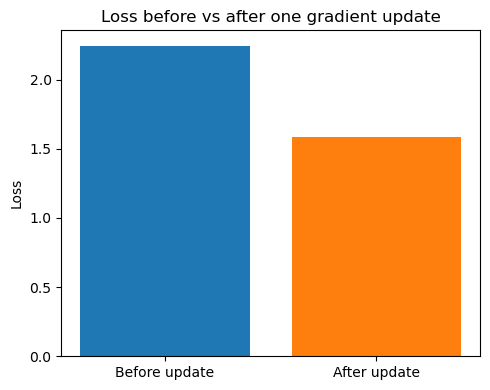

In [7]:
# Step 6: One manual update step — after applying gradients, loss should go down
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
optimizer.apply_gradients(zip(gradients, model.trainable_variables))

logits_after = model(x_batch, training=False)
loss_after = loss_fn(y_batch, logits_after)
print("Loss before update:", float(loss))
print("Loss after one update:", float(loss_after))
print("\nIf loss_after < loss, backprop + optimizer did their job: weights moved in the right direction.")

# Step 7: Plot loss before vs after one update (so we see the drop visually)
plt.figure(figsize=(5, 4))
plt.bar(["Before update", "After update"], [float(loss), float(loss_after)], color=["C0", "C1"])
plt.xlabel("")
plt.ylabel("Loss")
plt.title("Loss before vs after one gradient update")
plt.tight_layout()
plt.show()

---

## 🧩 Mini-exercise | تمرين مصغر

**Try it:** In a new code cell, print the gradient of the first layer's kernel (e.g. `gradients[0]`) and its shape. Then apply the optimizer step again (same cell or new) and print the loss again—does it decrease further?

---

## ✅ Summary | الملخص

**What you did:**
- Loaded a small batch of MNIST and built a tiny one-layer model.
- Used **GradientTape** to run a forward pass and compute **gradients** (backpropagation).
- Checked gradient shapes and one manual update step so loss decreased.

**In real life you'd also:** train for many steps (model.fit does forward + backprop + update in a loop); here we did one step to see the mechanism.

**The main idea:** Backpropagation gives us gradients of the loss w.r.t. each weight; the optimizer uses them to update weights so the loss goes down.

**Next:** `06_optimization_techniques` compares different optimizers (SGD, Adam, etc.) and how they use these gradients.
